<a href="https://colab.research.google.com/github/yaseen20051/crash-detection-cnn/blob/Branch_N/ahmed_crash_detection_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
import cv2
import os
import random

In [64]:
tf.keras.utils.set_random_seed(42)

# **Read Data**

In [65]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ckay16/accident-detection-from-cctv-footage")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'accident-detection-from-cctv-footage' dataset.
Path to dataset files: /kaggle/input/accident-detection-from-cctv-footage


# **Directories**

In [66]:
BASE_DIR = os.path.join(path, 'data')

train_dir = os.path.join(BASE_DIR, 'train')
val_dir = os.path.join(BASE_DIR, 'val')
test_dir=os.path.join(BASE_DIR, 'test')

In [67]:
classes = ["Accident", "Non Accident"]
for c in classes:
    train_path = os.path.join(train_dir, c)
    val_path = os.path.join(val_dir, c)
    test_path = os.path.join(test_dir, c)

# **Functions**

In [68]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

def load_images_and_labels(directory, label):
    images = []
    labels = []
    # List only files that are likely images to avoid errors with directories or hidden files
    image_files = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for filename in image_files:
        filepath = os.path.join(directory, filename)
        image = cv2.imread(filepath) # Use OpenCV to read imag
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)# convert from BGR to RGB
        image = cv2.resize(image, IMAGE_SIZE) # Resize image
        images.append(image)
        labels.append(label)
    return images, labels

# **Load Accident**

In [69]:
train_accident, y_train_accident = load_images_and_labels(
    os.path.join(train_dir, "Accident"),
    1
) # train_accident: train accident images , y_train_accident: train accident labels(1)

val_accident, y_val_accident = load_images_and_labels(
    os.path.join(val_dir, "Accident"),
    1
)

test_accident, y_test_accident = load_images_and_labels(
    os.path.join(test_dir, "Accident"),
    1
)

print("Train Accident:", len(train_accident))
print("Validation Accident:", len(val_accident))
print("Test Accident:", len(test_accident))

Train Accident: 369
Validation Accident: 46
Test Accident: 47


# **Load Non Accident**

In [70]:
train_non_accident, y_train_non_accident = load_images_and_labels(
    os.path.join(train_dir, "Non Accident"),
    0
) # train_accident: train non_accident images , y_train_accident: train non_accident labels(0)

val_non_accident, y_val_non_accident = load_images_and_labels(
    os.path.join(val_dir, "Non Accident"),
    0
)

test_non_accident, y_test_non_accident = load_images_and_labels(
    os.path.join(test_dir, "Non Accident"),
    0
)

print("Train Non Accident:", len(train_non_accident))
print("Validation Non Accident:", len(val_non_accident))
print("Test Non Accident:", len(test_non_accident))

Train Non Accident: 422
Validation Non Accident: 52
Test Non Accident: 53


# **Combine training data**

In [71]:
x_train = np.array(train_accident + train_non_accident) # contain all train images
y_train = np.array(y_train_accident + y_train_non_accident) # contain all train labels

print("x_train shape:",x_train.shape)
print("y_train shape:",y_train.shape)

x_train shape: (791, 224, 224, 3)
y_train shape: (791,)


# **Combine validation data**

In [72]:
x_val = np.array(val_accident + val_non_accident)
y_val = np.array(y_val_accident + y_val_non_accident)

print("x_val shape:",x_val.shape)
print("y_val shape:",y_val.shape)

x_val shape: (98, 224, 224, 3)
y_val shape: (98,)


# **Combine test data**

In [73]:
x_test = np.array(test_accident + test_non_accident)
y_test = np.array(y_test_accident + y_test_non_accident)

print("x_test shape:",x_test.shape)
print("y_test shape:",y_test.shape)

x_test shape: (100, 224, 224, 3)
y_test shape: (100,)


# **Shuffle the data**

In [74]:
def shuffle_data(images, labels):
    combined = list(zip(images, labels))
    random.shuffle(combined)

    shuffled_images, shuffled_labels = zip(*combined)

    return np.array(shuffled_images), np.array(shuffled_labels)

In [75]:
x_train, y_train = shuffle_data(x_train, y_train)
x_val, y_val = shuffle_data(x_val, y_val)
x_test, y_test = shuffle_data(x_test, y_test)

# **image Preprocessing**

In [76]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
x_train= preprocess_input(x_train)
x_test= preprocess_input(x_test)
x_val= preprocess_input(x_val)

# **Augmentation**

In [77]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1)
])

# **Model Creation**

In [78]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224,224, 3),
    include_top=False, # cut output layer
    weights="imagenet"
)
base_model.trainable = False

In [79]:
model = keras.Sequential([
    keras.layers.Input(shape=(224,224,3)),
    data_augmentation,
    base_model,

    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(1, activation="sigmoid")
])

# **Model Summary**

In [80]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Model Compilation**

In [81]:
model.compile(
    optimizer ="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# **Model Training**

In [82]:
early_stopping=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=5,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=5,
)

In [83]:
history=model.fit(x_train,y_train,
                  epochs=40,batch_size=BATCH_SIZE,
                  validation_data=(x_val,y_val),callbacks=[early_stopping])

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.5474 - loss: 0.8520 - val_accuracy: 0.6327 - val_loss: 0.6466
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6372 - loss: 0.6267 - val_accuracy: 0.6735 - val_loss: 0.6266
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.6713 - loss: 0.5936 - val_accuracy: 0.6735 - val_loss: 0.5823
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.7155 - loss: 0.5557 - val_accuracy: 0.7245 - val_loss: 0.5678
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.7004 - loss: 0.5428 - val_accuracy: 0.7143 - val_loss: 0.5453
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.7219 - loss: 0.5382 - val_accuracy: 0.7449 - val_loss: 0.5345
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7573 - loss: 0.4974 - val_accuracy: 0.7245 - val_loss: 0.5465
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7522 - loss: 0.4919 - val_accuracy: 0.7551 - 

# **Visualization**

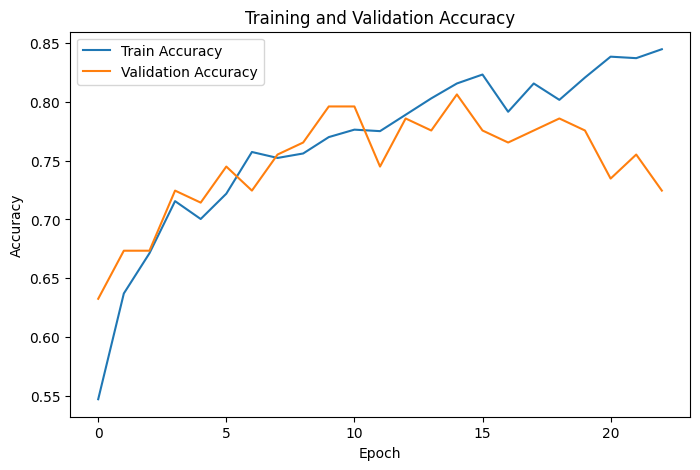

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

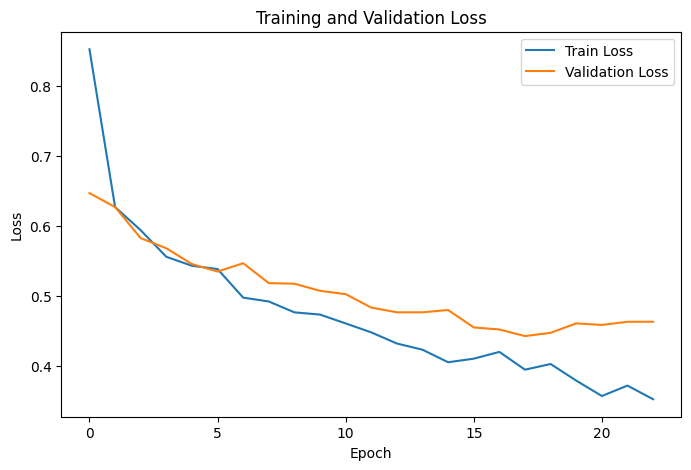

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

# **Evaluation**

In [86]:
y_train_pred_prob = model.predict(x_train)
y_train_pred = (y_train_pred_prob >= 0.4).astype(int).ravel()

y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob >= 0.4).astype(int).ravel()

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [87]:
print("train classification_report:")
print(classification_report(y_train,y_train_pred))
print("test classification_report:")
print(classification_report(y_test, y_pred))

train classification_report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       422
           1       0.83      0.80      0.82       369

    accuracy                           0.83       791
   macro avg       0.83      0.83      0.83       791
weighted avg       0.83      0.83      0.83       791

test classification_report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        53
           1       0.87      0.87      0.87        47

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



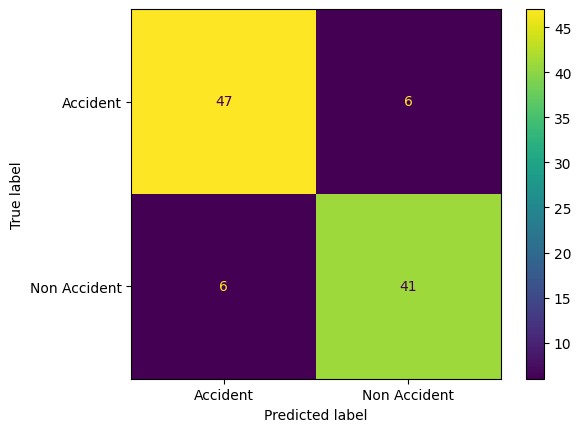

In [88]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
disp.plot()
plt.show()